In [16]:
import matplotlib.pyplot as plt
from labdata.schema import *
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
#%matplotlib widget

savepath = Path(r'C:\Data\churchland\chronic_manuscript_figs\raw_plots\longitudinal_unit_count')
savepath.mkdir(parents = True,exist_ok = True)

In [17]:
# fit a line to the data
def fit_line(x,y):
    # fit exponential decay
    coeffs = np.polyfit(x, np.log(y), 1)
    return coeffs


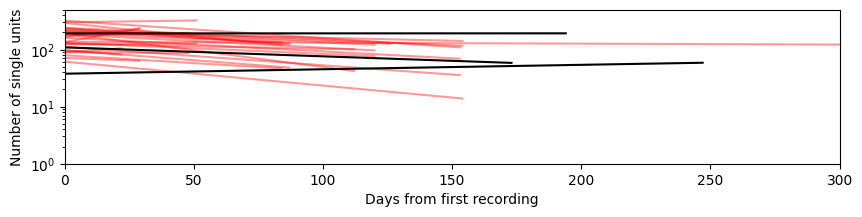

In [27]:
# units yield over time
# plt.figure(figsize = (3,3))
from scipy.stats import linregress


plt.figure(figsize = (10,2))
markers = ['.','s','^','d','<','D','>','p','>','h','H','.','s','^','d','|','_']
plt2cols = []
c = 0
# subjects = ['JC131', 'MM008', '_AL031', '_AL036']
subjects = ['JC131', 'JC162','JC142','MM018','MM013','MM030','_AL031', '_AL036','_AL032']
subjects = ['JC119','JC131','JC140','JCC141','JC142','JC162','JC164','MM008','MM012','MM013','MM015','MM018','MM030','_AL031', '_AL036','_AL032']
parameter_set_num = 5
unit_criteria_id = 7
color = '#d62728'
pc_cement, pc_indie = [], []
ln_cement, ln_indie = [], []
ln, pc = [], []
significant = []
for i,s in enumerate(subjects):
    probenums = (EphysRecording.ProbeSetting & dict(subject_name=s, parameter_set_num=5)).fetch('probe_num')
    n_probes = np.unique(probenums)
    for p in n_probes:
        config_ids = (Session * EphysRecording.ProbeSetting * UnitCount & dict(subject_name=s, probe_num=p, 
                                                                               parameter_set_num=parameter_set_num,
                                                                               unit_criteria_id=unit_criteria_id)).fetch('configuration_id')
        ids, counts = np.unique(config_ids, return_counts=True)
        config_id = ids[np.argmax(counts)]
        #print(f'Using configuration ID {config_id} for subject {s}, probe {p}')
        query = EphysRecording.ProbeSetting * Session * UnitCount & dict(probe_num=p, subject_name=s, 
                                                                         configuration_id=config_id, 
                                                                         unit_criteria_id=unit_criteria_id,
                                                                         parameter_set_num=parameter_set_num)
        datetimes, nsua = query.fetch('session_datetime','sua')
        delta_days = (datetimes - datetimes[0]).astype('timedelta64[D]').astype(int)
        target_delta=10
        targeted_days = np.arange(np.random.uniform(0,target_delta/2), np.max(delta_days)+target_delta+1, target_delta).astype(int)
        session_inds_to_use = np.unique([np.absolute(delta_days-target_day).argmin() for target_day in targeted_days])
        #if '_' not in s:
        #    continue

        if (len(nsua) < 3) or (delta_days[-1] < 14):
            # skip if fewer than three sortings, or if the recording is less than 2 weeks
            continue
        mask = nsua > 0
        coeffs = fit_line(delta_days[mask], nsua[mask])
        percent_change = (np.exp(coeffs[0]) - 1) * 100
        log_neurons_per_day = coeffs[0]
        # compute if the slope is significantly different from zero
        #alpha = 0.05
        #res = linregress(delta_days[mask], np.log(nsua)[mask])
        ##a = res.slope
        #p_value = res.pvalue
        #if p_value < alpha:
        #    significant.append(1)
        #else:
        #    significant.append(0)
        if np.abs(log_neurons_per_day) > 0.05:
            print(f'{s} probe {p}: {percent_change:.2f}% change per day, log(neurons/day)={log_neurons_per_day:.4f}')

        xx = np.linspace(0, max(delta_days), 100)
        yy = np.exp(coeffs[0] * xx + coeffs[1])
        if '_' in s:
            plt.plot(xx, yy, label=f'{s} probe {p}', color='k')
            plt2cols.append('k')
        else:
            ln.append(log_neurons_per_day)
            pc.append(percent_change)
            plt.plot(xx, yy, label=f'{s} probe {p}', color='red', alpha=.4)
            plt2cols.append('red')
significant = np.array(significant)
        
        #if '_' in s:
        #    plt.scatter(delta_days[session_inds_to_use], nsua[session_inds_to_use], s=10, color='black',facecolors = 'none', marker=markers[c],alpha = 1)
        #    plt.plot(delta_days[session_inds_to_use], nsua[session_inds_to_use], color='black', alpha=0.7, linewidth=1)
        #else:
        #    plt.scatter(delta_days[session_inds_to_use], nsua[session_inds_to_use], s=10,  color=color, facecolors = 'none', marker=markers[c],alpha = 1)
        #    plt.plot(delta_days[session_inds_to_use], nsua[session_inds_to_use], color=color, alpha=0.7, linewidth=1)
            
# make y axis log scale
plt.ylim(1, 500)
plt.xlim(0,300)
plt.xlabel('Days from first recording')
plt.ylabel('Number of single units')
plt.savefig(savepath / 'line_fits.pdf', bbox_inches = 'tight')
# set y axis to log scale
plt.yscale('log')
plt.savefig(savepath / 'line_fits_log.pdf', bbox_inches = 'tight')

In [32]:
savepath

WindowsPath('C:/Data/churchland/chronic_manuscript_figs/raw_plots/longitudinal_unit_count')

In [28]:
# load the steinmetz drift slopes
from scipy.io import loadmat
STEINMETZ_DATAPATH = Path().resolve().parent / 'data' / 'steinmetz_slope.mat'

steinmetz_slopes = loadmat(STEINMETZ_DATAPATH)['yield_slope']
steinmetz_slopes = np.sort(steinmetz_slopes).squeeze()


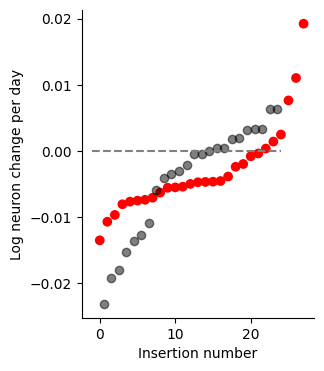

In [31]:
# log change in neurons per day
plt.figure(figsize=(3,4))
#plt.ylim(-.025,.025)
sortinds = np.argsort(ln)
ln = np.array(ln)[sortinds]
plt2cols = np.array(plt2cols)[sortinds]
#significant = significant[sortinds]
#plt.scatter(np.arange(len(ln)),ln, marker='o', color=plt2cols)
plt.scatter(np.arange(len(ln)),ln, marker='o', color=plt2cols)
plt.scatter(np.arange(len(steinmetz_slopes)) + .5, steinmetz_slopes, marker='o', alpha=.5, color='k')
# hline at zero within plot limits
plt.hlines(0, xmin=-1, xmax=len(steinmetz_slopes), colors='gray', linestyles='dashed')
plt.ylabel('Log neuron change per day')
plt.xlabel('Insertion number')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig(savepath / 'log_neuron_change_per_day.pdf', dpi=800, bbox_inches='tight')


Mean percent change in single units per day: -0.47%


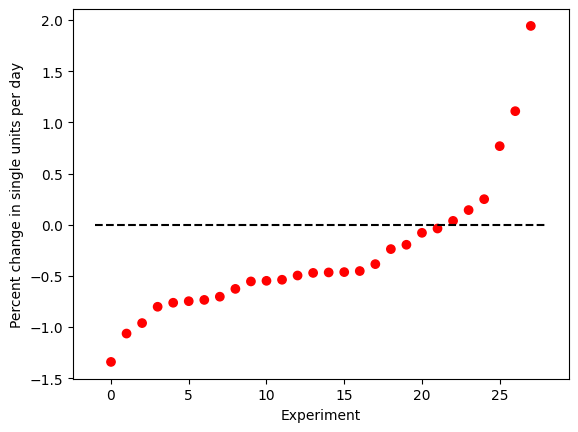

In [30]:
# plot percent change in single units per day
plt.figure()
sortinds = np.argsort(pc)
pc = np.array(pc)[sortinds]
#
plt.scatter(np.arange(len(pc)),pc, marker='o', color=plt2cols)
plt.ylabel('Percent change in single units per day')
plt.xlabel('Experiment')
plt.hlines(0, -1, max(len(pc), len(pc)), linestyles='dashed', color='k')
print(f'Mean percent change in single units per day: {np.median(pc):.2f}%')

In [22]:
# run stats to see if steinmetz_slopes or ln is bigger
# use a parametric t test and a non parametric mann whitney u test
from scipy.stats import ttest_ind, mannwhitneyu
t_stat, p_val = ttest_ind(ln, steinmetz_slopes)
u_stat, p_val_u = mannwhitneyu(ln, steinmetz_slopes)
print(f'T-test: t={t_stat:.3f}, p={p_val:.3f}')
print(f'Mann-Whitney U test: U={u_stat:.3f}, p={p_val_u:.3f}')

T-test: t=0.633, p=0.530
Mann-Whitney U test: U=306.000, p=0.588
